# QNN From Scratch: End-to-End Notebook

This notebook demonstrates a complete workflow with the project:

- dataset generation and visualization
- model construction and forward behavior
- gradient inspection
- training dynamics
- evaluation with confusion matrix
- parameter and prediction diagnostics


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from qnn.datasets import make_classification_dataset, train_test_split
from qnn.metrics import confusion_matrix_binary
from qnn.qnn import DataReuploadingQNN
from qnn.trainer import Trainer, TrainingConfig

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

## 1) Generate and visualize data

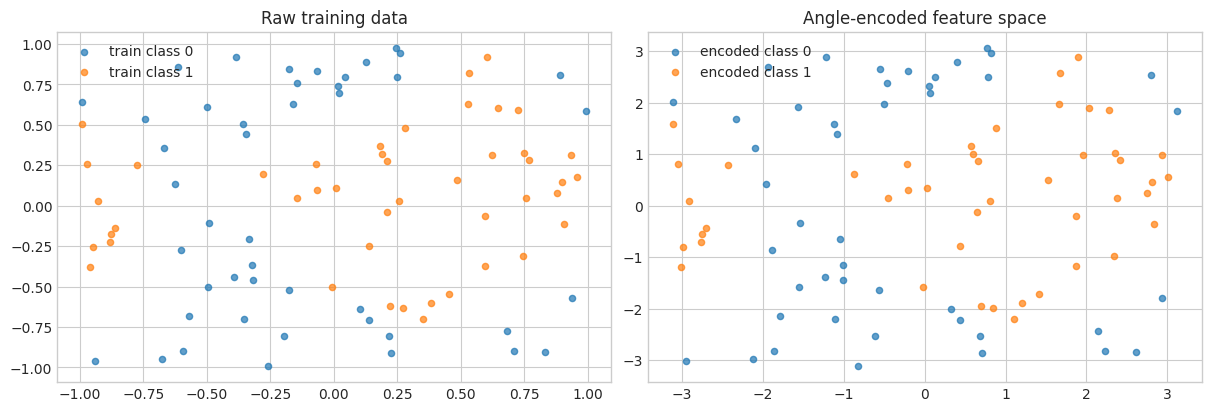

In [2]:
X_all, y_all, raw_all = make_classification_dataset(num_samples=120, kind="sine", noise=0.1, seed=7)
dataset = train_test_split(X_all, y_all, raw_all, test_size=30 / 120, seed=7, shuffle=True)
X_train, y_train, X_test, y_test = dataset.X_train, dataset.y_train, dataset.X_test, dataset.y_test
raw_train, raw_test = dataset.raw_train, dataset.raw_test

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ax[0].scatter(
    raw_train[y_train == 0, 0], raw_train[y_train == 0, 1], s=20, label="train class 0", alpha=0.7
)
ax[0].scatter(
    raw_train[y_train == 1, 0], raw_train[y_train == 1, 1], s=20, label="train class 1", alpha=0.7
)
ax[0].set_title("Raw training data")
ax[0].legend()

ax[1].scatter(
    X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=20, label="encoded class 0", alpha=0.7
)
ax[1].scatter(
    X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=20, label="encoded class 1", alpha=0.7
)
ax[1].set_title("Angle-encoded feature space")
ax[1].legend()
plt.show()

## 2) Build model and inspect initial behavior

Parameter tensor shape: (3, 2, 3)
Initial parameter summary -> mean: -0.043576355379671604 std: 0.1642812157207117


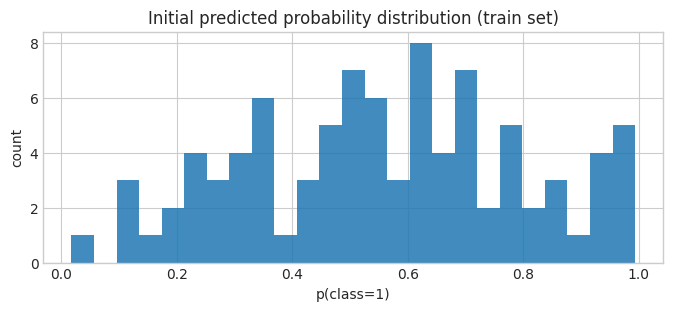

In [3]:
model = DataReuploadingQNN(num_qubits=2, num_layers=3, num_features=2, observable_wire=1, seed=7)
print("Parameter tensor shape:", model.params.shape)
print("Initial parameter summary -> mean:", model.params.mean(), "std:", model.params.std())

initial_proba = model.predict_proba(X_train)
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(initial_proba, bins=25, alpha=0.85)
ax.set_title("Initial predicted probability distribution (train set)")
ax.set_xlabel("p(class=1)")
ax.set_ylabel("count")
plt.show()

## 3) Inspect gradient magnitudes before training

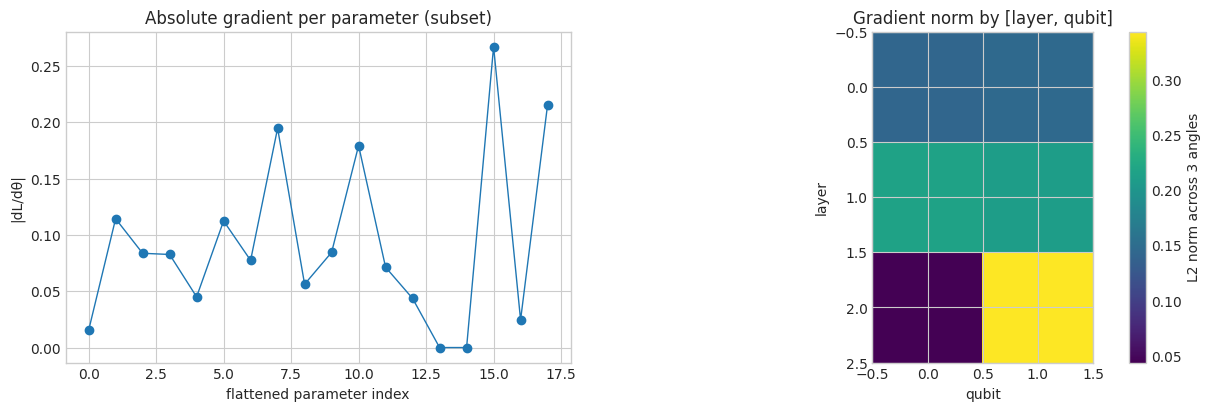

In [4]:
subset_X = X_train[:24]
subset_y = y_train[:24]
grad0 = model.parameter_shift_gradient(subset_X, subset_y)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ax[0].plot(np.abs(grad0).ravel(), marker="o", lw=1)
ax[0].set_title("Absolute gradient per parameter (subset)")
ax[0].set_xlabel("flattened parameter index")
ax[0].set_ylabel("|dL/dθ|")

im = ax[1].imshow(np.linalg.norm(grad0, axis=2), cmap="viridis")
ax[1].set_title("Gradient norm by [layer, qubit]")
ax[1].set_xlabel("qubit")
ax[1].set_ylabel("layer")
fig.colorbar(im, ax=ax[1], label="L2 norm across 3 angles")
plt.show()

## 4) Train model and plot learning curves

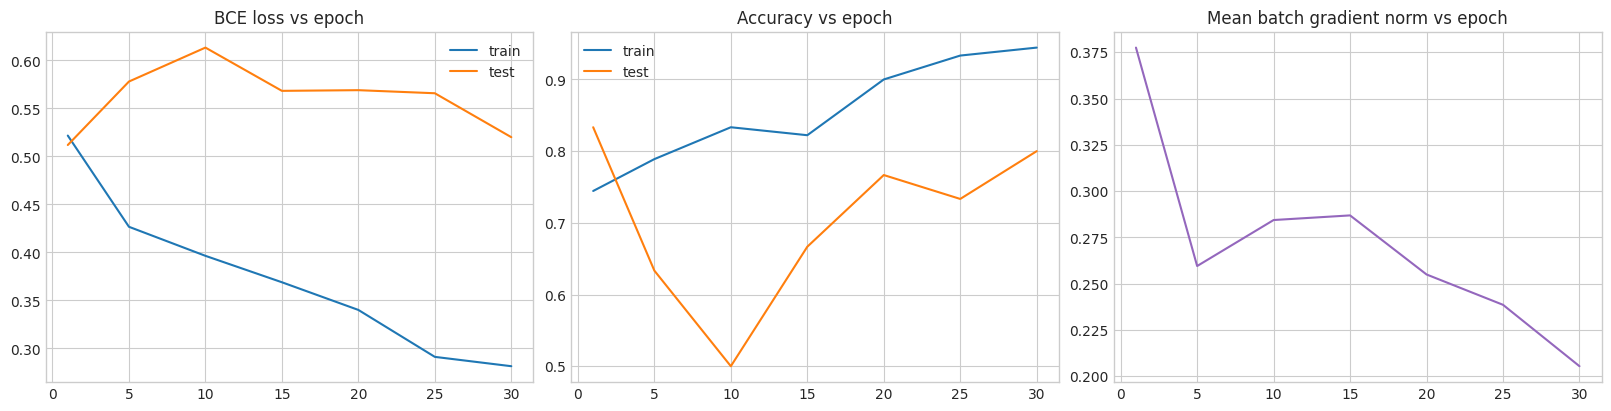

In [5]:
cfg = TrainingConfig(
    epochs=30,
    learning_rate=0.1,
    batch_size=16,
    grad_clip=2.0,
    log_every=5,
    output_dir="outputs/notebook_run",
)
trainer = Trainer(model=model, config=cfg)
history = trainer.fit(X_train, y_train, X_test, y_test)

epochs = np.array([r.epoch for r in history])
train_loss = np.array([r.train_loss for r in history])
test_loss = np.array([r.test_loss for r in history])
train_acc = np.array([r.train_accuracy for r in history])
test_acc = np.array([r.test_accuracy for r in history])
grad_norm = np.array([r.grad_norm for r in history])

fig, ax = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
ax[0].plot(epochs, train_loss, label="train")
ax[0].plot(epochs, test_loss, label="test")
ax[0].set_title("BCE loss vs epoch")
ax[0].legend()

ax[1].plot(epochs, train_acc, label="train")
ax[1].plot(epochs, test_acc, label="test")
ax[1].set_title("Accuracy vs epoch")
ax[1].legend()

ax[2].plot(epochs, grad_norm, color="tab:purple")
ax[2].set_title("Mean batch gradient norm vs epoch")
plt.show()

## 5) Evaluate decision boundary and confusion matrix

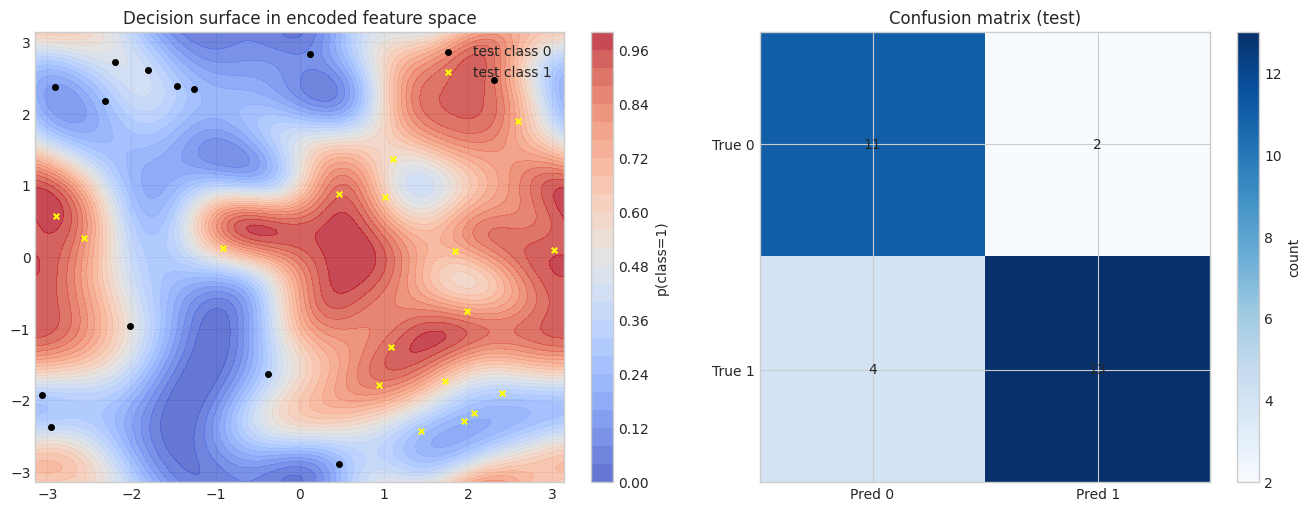

In [6]:
grid = np.linspace(-np.pi, np.pi, 160)
xx, yy = np.meshgrid(grid, grid)
mesh = np.column_stack([xx.ravel(), yy.ravel()])
mesh_p = model.predict_proba(mesh).reshape(xx.shape)

test_p = model.predict_proba(X_test)
cm = confusion_matrix_binary(test_p, y_test)

fig, ax = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
cont = ax[0].contourf(xx, yy, mesh_p, levels=25, cmap="coolwarm", alpha=0.8)
ax[0].scatter(
    X_test[y_test == 0, 0],
    X_test[y_test == 0, 1],
    s=16,
    c="black",
    marker="o",
    label="test class 0",
)
ax[0].scatter(
    X_test[y_test == 1, 0],
    X_test[y_test == 1, 1],
    s=16,
    c="yellow",
    marker="x",
    label="test class 1",
)
ax[0].set_title("Decision surface in encoded feature space")
ax[0].legend(loc="upper right")
fig.colorbar(cont, ax=ax[0], label="p(class=1)")

mat = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
im = ax[1].imshow(mat, cmap="Blues")
ax[1].set_xticks([0, 1], ["Pred 0", "Pred 1"])
ax[1].set_yticks([0, 1], ["True 0", "True 1"])
ax[1].set_title("Confusion matrix (test)")
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, str(mat[i, j]), ha="center", va="center")
fig.colorbar(im, ax=ax[1], label="count")
plt.show()

## 6) Save and inspect artifacts

In [7]:
out_dir = trainer.save_artifacts(X_train, y_train, X_test, y_test, raw_test=raw_test)
print("Saved to:", out_dir)
summary = json.loads((Path(out_dir) / "summary.json").read_text())
summary

Saved to: outputs/notebook_run


{'final': {'epoch': 30,
  'train_loss': 0.28141116199879945,
  'train_accuracy': 0.9444444444444444,
  'test_loss': 0.5199839027105531,
  'test_accuracy': 0.8,
  'grad_norm': 0.20536889376119882},
 'confusion_matrix_test': {'tn': 11, 'fp': 2, 'fn': 4, 'tp': 13}}